## Trabajo Advance Topics

El trabajo se divide en cuatro partes, en cada parte hay que realizar una predicción para cada una de las partes.



La primera parte del trabajo consiste en hacer una clasificación binaria para predecir si los estudiantes presentan miopia o no la presentan. Estos datos se encuentran codificados en la columna M (YES or NO). MM especifíca más de seis dioptrías.

Primero vamos a ver en que consiste nuestro conjunto de test.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Empezamos realizando los imports más básicos y leyendo los csv

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('Y_train.csv')

In [ ]:
X_train.isna().sum().sum(), y_train.isna().sum()

(np.int64(287),
 M         0
 MM        0
 Combo     0
 DCombo    0
 dtype: int64)

Como podemos ver tenemos datos faltantes en el conjunto de xtrain pero no en el del ytrain, por lo que para hacer el preprocesamiento de datos voy a juntar todo el conjunto de train para que todos los datos que elimine o los faltantes los elimine tanto de el xtrain como del ytrain.

In [ ]:
DF = pd.concat([X_train, y_train], axis = 1)
print(f'Ahora el nuevo DataFrame contiene los features y los labels: {DF.shape}')

Ahora el nuevo DataFrame contiene los features y los labels: (132, 53)


Hay columnas que podemos eliminar antes de realizar el Análisis EDA, ya que, por ejemplo la columna *'hº act.cerca'* se encuentra vacía, o la de fecha que no aporta ningún tipo de información.


In [ ]:
DF = DF.drop(columns=['hº act.cerca sem','fecha'])

Podemos seguir por este camino, por ejemplo las columnas con un determinado número de missing values pueden entorpecer el análisis y el modelo futuro, por lo que lo primero que vamos a hacer es quitarnos las columnas con más de un 40% de missing values, y luego veremos que porcentaje tenmos en las siguiente y consideraremos según la importancia que le demos si la quitamos directamente o la imputamos con la media, moda...

In [ ]:
missing = DF.isna().mean()*100

missing = missing.rename('Missing')

missing = missing.rename("porcentaje").reset_index().rename(columns={'index':'feature'})


In [ ]:
missing = DF.isna().mean()*100

missing = missing.rename('Missing')

missing = missing.rename("porcentaje").reset_index().rename(columns={'index':'feature'})

cols_drop = missing[missing['porcentaje'] > 40]['feature']

print(f'Columnas que quitaremos ya que presentan más de un 40% de MissingValues: {cols_drop.values}')

DF = DF.drop(columns = cols_drop)

Columnas que quitaremos ya que presentan más de un 40% de MissingValues: ['origen antepasados (extranjeros)']


Para eliminar el resto de valores faltantes de nuestras features vamos a seguir diferentes estrategias segun el tipo de dato que tengamos.

Para las columnas categoricas (fototipo , antepasados (españa) ...) vamos a rellenar creando una nueva clase que se llame Desconodido para no inventar datos y sesgar .

Para las numercias de tiempo (hº ocio exteriores sem , horas interior sem .. ) vamos a sustituir por la mediana de la columna

In [ ]:
cols_cat = ['fototipo', 'Grupo fot', 'origen antepasados (españa)', 'familiar miope', 'pat. Ret. Miop magna']
for col in cols_cat:
    DF[col] = X_train[col].fillna('Desconocido')

cols_num = ['hº ocio exteriores sem', 'horas interior sem', 'Familiar miope num.']
for col in cols_num:
    DF[col] = X_train[col].fillna(X_train[col].median())


In [ ]:
DF.isna().sum().sum()

np.int64(0)

Una vez eliminados los NA vamos a hacer el encodding (Convertir el texto a numeros) Para que la red pueda aprender bien los diferentes grupos para las columnas categoricas y a escalar (media 0 y std 1 ) los datos de las columnas numericas


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Separamos todas las columnas numericas y categoricas
categoricas = []
numericas = []

# volvemos a separar las X de las y
y_finales = DF.iloc[:, -4:]

In [ ]:
y_clasificacion = y_finales['M']  # nos quedamos solo con la columna de miopia para la clasificacion
X = DF.iloc[:, :-4]

for col in X.columns :
    if X[col].dtype == 'object':
      categoricas.append(col)
    else :
      numericas.append(col)

scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_cat = encoder.fit_transform(X[categoricas])

X_num = scaler.fit_transform(X[numericas])

X_final = np.concatenate((X_cat,X_num), axis = 1)

y_clasificacion = y_clasificacion.map({'NO':0 , 'SI':1})



Por ultimo solo nos queda pasar a tensores y hacer el dataloader

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


X_tensor = torch.tensor(X_final, dtype=torch.float32)
y_tensor = torch.tensor(y_clasificacion, dtype=torch.float32).unsqueeze(1) #ajustamos dim

valores_unicos, conteos = y_tensor.unique(return_counts=True)

print(f"Clases: {valores_unicos}")
print(f"Cantidad por clase: {conteos}")

Clases: tensor([0., 1.])
Cantidad por clase: tensor([44, 88])


Separamos nuestros datos para poder ver si lo estamos haciendo bien

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size = 0.2,  random_state = 42)

In [ ]:
dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

Una vez ya tenemos tanto el conjunto de test como el de train en formatos adecuados para aplicarles el training loop podemos definir un modelo para nuestra clasificacion binaria. Para este primer apartado realizaremos un red.

In [ ]:
def training_loop(n_epochs, model, optimizer, loss_fn, dataloader ,  xtrain,ytrain):
    for epoch in range(1,n_epochs+1):
        loss_total = 0
        loss_train = []
        for x_bach , y_bach in dataloader:
            y_pred = model(x_bach)
            loss = loss_fn(y_pred, y_bach)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_total += loss.item()
        loss_train.append(loss_total)
        if epoch == 1 or epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss {loss_total:.4f}")
    return loss_train

Hemos visto que una de las calses esta mas desequilibrada que la otra en una relacion de mas o menos un 2 a 1. Por eso aunque no es dramatico para mejorar nuestro modelo hemos decidido usar como funcion de perdida en vez del BCEloss la funcion BCEWithLogitsLoss. Esta es muy similar a la otra pero nos permite usar pos_weight (muy util para equilibrar la clase minoritaria dando mas importancia) . El unico cambio importante que nos obliga a hacer esta funcion es que no podemos poner la funcion sigmoide a la salida de nuestro modelo y se tendra que poner fuera a la hora de calcular las metricas .


In [ ]:
input_size = x_train.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, 32),
    nn.LeakyReLU(0.01),
    nn.Dropout(0.4),
    nn.Linear(32, 16),
    nn.LeakyReLU(0.01),
    nn.Linear(16, 1)
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([44 / 88]))
# El pos_weight se usa para equilibrar el aprendizaje al dar mayor importancia a los errores cometidos en la clase minoritaria,
# evitando así que el modelo se sesgue hacia la clase que más se repite. Numero de negativos(0)/Numero positivos (1)

optimizer = optim.Adam(model.parameters(), lr = 1e-3, weight_decay = 1e-4)

train_loss = training_loop(
    n_epochs = 1000,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    dataloader = train_loader,
    xtrain = x_train,
    ytrain = y_train,
)

Epoch 1, Loss 3.1420
Epoch 500, Loss 0.0044
Epoch 1000, Loss 0.0023


In [ ]:
accuracy_total = 0
model.eval()
for i in range(1,10000):
    with torch.no_grad():
         preds = model(x_test)
         preds = torch.sigmoid(preds) # PASAMOS POR LA SIGMOIDE AHORA PORQUE LA FUNCION DE PERDIDA QUE USAMOS NO PERMITE ANTES
         preds = (preds > 0.5).float()
         aciertos = (preds == y_test).sum()
         accuracy_total += (aciertos / y_test.shape[0]) * 100

print(accuracy_total/10000)

tensor(88.8707)


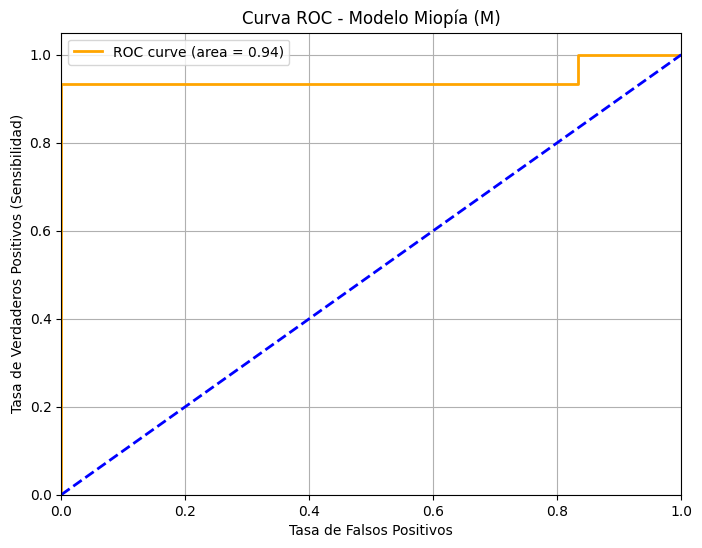

In [ ]:
from sklearn.metrics import roc_curve, auc

model.eval()
with torch.no_grad():
    logits = model(x_test)
    probs = torch.sigmoid(logits).numpy()

# Calculamos la curva con las PROBS
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# Dibujamos
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--') # Línea de azar
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Modelo Miopía (M)')
plt.legend()
plt.grid()
plt.show()

Accuracy: 88.89%
Precision: 89.20%
Recall: 88.33%
F1 Score: 88.64%


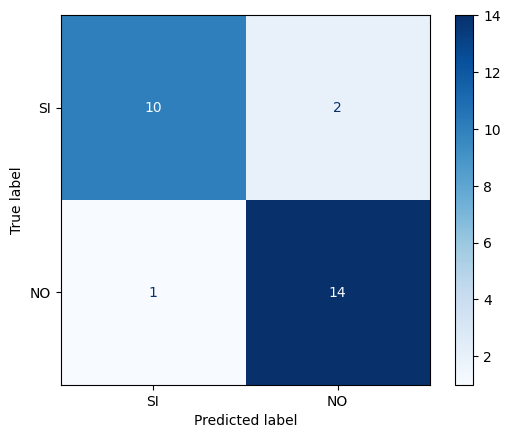

In [ ]:
from sklearn import metrics

accuracy = metrics.accuracy_score(y_test, preds)
preccision = metrics.precision_score(y_test, preds, average='macro')
recall = metrics.recall_score(y_test, preds, average='macro')
f1_score = metrics.f1_score(y_test, preds, average='macro')

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {preccision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1 Score: {f1_score*100:.2f}%")

cm = metrics.confusion_matrix(y_test, preds)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['SI', 'NO'])
disp.plot(cmap=plt.cm.Blues)
plt.show()


Para asegurar la robustez del modelo vamos a aplicar cross validation. Vamos a usar 5 Folds (particiones) .Esto significa que entrenaremos 5 modelos desde cero, cada uno usando el 80% de los datos para entrenar y el 20% para validar, rotando hasta evaluar el 100% del dataset.

Esto es muy importante ya que los datos son muy pocos, entonces asi nos aseguramos de que no estamos haciendo overfitting y de que nuestras metricas no son azar

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score


X_cross = X_tensor.numpy() # pasamos a numpy para que sklearn haga las particiones fácilmente
y_croos = y_tensor.numpy()

k_folds = 5

skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

resultados_acc = []
resultados_auc = []


lista_modelos = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cross, y_croos)):

    # Separar los datos del fold y pasar a tensor
    X_train = torch.tensor(X_cross[train_idx], dtype=torch.float32)
    y_train = torch.tensor(y_croos[train_idx], dtype=torch.float32)

    X_val = torch.tensor(X_cross[val_idx], dtype=torch.float32)
    y_val = torch.tensor(y_croos[val_idx], dtype=torch.float32)

    # Dataloader
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

    # Calcular el pos_weight exacto para los datos de entrenamiento del fold
    num_positivos = y_train.sum().item()
    num_negativos = len(y_train) - num_positivos
    peso_pos = num_negativos / num_positivos

    # Importante definir un modelo nuevo en cada fold
    input_size = X_train.shape[1]
    model = nn.Sequential(
        nn.Linear(input_size, 16),
        nn.LeakyReLU(0.01),
        nn.Dropout(0.6),
        nn.Linear(16, 8),
        nn.LeakyReLU(0.01),
        nn.Linear(8, 1)
    )



    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([peso_pos]))
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-3)


    # 5. Bucle de Entrenamiento
    epochs = 100
    model.train()
    for epoch in range(epochs):
      for inputs, labels in train_loader:
          optimizer.zero_grad()
          logits_pred = model(inputs)
          loss = loss_fn(logits_pred, labels)
          loss.backward()
          optimizer.step()


    # 6. Evaluación del Fold
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val)
        val_probs = torch.sigmoid(val_logits)
        val_preds_binarias = (val_probs >= 0.5).float()

        acc = accuracy_score(y_val.numpy(), val_preds_binarias.numpy())
        auc = roc_auc_score(y_val.numpy(), val_probs.numpy())

        resultados_acc.append(acc * 100)
        resultados_auc.append(auc)

        print(f"Accuracy: {acc*100:.2f}% | AUC-ROC: {auc:.4f}")

  # guardamos los modelos
    lista_modelos.append(model)

print(f"Accuracy Media: {np.mean(resultados_acc):.2f}% (± {np.std(resultados_acc):.2f}%)")
print(f"AUC-ROC Medio:  {np.mean(resultados_auc):.4f} (± {np.std(resultados_auc):.4f})")

Accuracy: 88.89% | AUC-ROC: 0.9321
Accuracy: 92.59% | AUC-ROC: 0.9630
Accuracy: 65.38% | AUC-ROC: 0.6875
Accuracy: 88.46% | AUC-ROC: 0.9020
Accuracy: 73.08% | AUC-ROC: 0.8170
Accuracy Media: 81.68% (± 10.55%)
AUC-ROC Medio:  0.8603 (± 0.0992)


Para obtener el modelo definitivo vamos a seguir una estrategia de votacion en la que con los 5 modelos que hemos hecho en el cross validation haremos la prediccion en base a la media de todos juntos

In [ ]:
X_total_tensor = torch.tensor(X_cross, dtype=torch.float32)
y_total_tensor = torch.tensor(y_croos, dtype=torch.float32)


for m in lista_modelos:
     m.eval()

probabilidades_totales = []

with torch.no_grad():
    for m in lista_modelos:
        # Sacamos las probabilidades de cada modelo (0 a 1)
        logits = m(X_total_tensor)
        probs = torch.sigmoid(logits)
        probabilidades_totales.append(probs)

    # Promediamos las probabilidades de los 5 modelos
    media_probs = torch.stack(probabilidades_totales).mean(dim=0)

    # Clasificamos >= 0.5 si , menor no
    predicciones_finales = (media_probs >= 0.5).float()


# Calcular métrica final del Ensemble
final_acc = accuracy_score(y_total_tensor.numpy(), predicciones_finales.numpy())
final_auc = roc_auc_score(y_total_tensor.numpy(), predicciones_finales.numpy())

print(f"Accuracy Ensamble model: {final_acc*100:.2f}%")
print(f"AUC-ROC:  {final_auc:.4f}")

Accuracy Ensamble model: 96.97%
AUC-ROC:  0.9773


Importante destacar que para enviar las predicciones que hagamos en el archivo .txt vamos a eliminar la separacion de train y test para entrenar el modelo con la mayor cantidad de datos posibles ya que posteriormente seran evaluado con un set de test diferente

# Parte 2

Como ahora estamos buscando un tipo especifico de miopia (+6 dioprias) nuesto grupo de miopina magna va a ser todavia mas pequeño que antes y sumado a que tampoco tenemos tantas columnas hemos decidido hacer un Random Forest con diferentes datasets generados a partir de remuestreos de Bootstrap.

In [ ]:
y_ensamble_forest = y_finales['MM']
y_ensamble_forest = y_ensamble_forest.map({'NO':0 , 'SI':1})

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
modelo_mm = RandomForestClassifier(
    n_estimators= 100,        # Número de árboles
    max_depth= None,
    class_weight='balanced',
    random_state=42
)

x_train, x_test, y_train, y_test = train_test_split(X_final, y_ensamble_forest, test_size = 0.2,stratify = y_tensor, random_state = 42)

smote = SMOTE(random_state=42, k_neighbors = 3)
x_train, y_train = smote.fit_resample(x_train, y_train)
modelo_mm.fit(x_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
accuracy = modelo_mm.score(x_test, y_test)
print(f"Accuracy del Random Forest: {accuracy * 100:.2f}%")

Accuracy del Random Forest: 92.59%


In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, modelo_mm.predict(x_test)))

[[25  0]
 [ 2  0]]


El modelo devido a la gran poca cantidad de casos con Miopima magna no detecta estos . Por eso creemos que es mejor bajar el humbral a 0.25.

In [ ]:
probabilidades = modelo_mm.predict_proba(x_test)[:, 1]
preds_agresivas = (probabilidades > 0.20).astype(int)

print(confusion_matrix(y_test, preds_agresivas))
accuracy = modelo_mm.score(x_test, y_test)
print(f"Accuracy del Random Forest: {accuracy * 100:.2f}%")

[[24  1]
 [ 0  2]]
Accuracy del Random Forest: 92.59%


Ahora si somos capaces de detectar  la miopia magna a pesar de tener 3 falsos positivos, los cuales seguramente tengan miopia alta pero sin llegar a ser magna.

# Parte 3

In [ ]:
y_forest2 = y_finales['Combo']
y_forest2 = y_forest2.map({'C':0 , 'M':1 , 'MM':2})


In [ ]:
modelo_combo = RandomForestClassifier(
    n_estimators=1000,
    max_depth= None,
    class_weight = 'balanced',
    random_state=42
)

x_train, x_test, y_train, y_test = train_test_split(X_final, y_forest2, stratify = y_tensor, test_size = 0.2, random_state = 42)
sm = SMOTE(random_state=42, k_neighbors = 4)
x_train, y_train = sm.fit_resample(x_train, y_train)
modelo_combo.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=42)

In [ ]:
y_pred_combo = modelo_combo.predict(x_test)

accuracy_combo = modelo_combo.score(x_test, y_test)
print(accuracy_combo )
print("-" * 30)

# Matriz de Confusión
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_combo))



0.8518518518518519
------------------------------
Matriz de Confusión:
[[ 7  2  0]
 [ 2 12  0]
 [ 0  0  4]]


# Parte 4

Para el ultimo modelo vamos a intenar usar el primer modelo para distinguir entre paciente con Miopia del que No la tiene . Luego si tienene miopia usaremos el primer RandomForest para diferenciar entre MM y Miopina normal y por ultimo haremos un modelo nuevo para separar estos con Miopia entre M1 y M2 .

In [ ]:
y4 = y_finales['DCombo']
y4 = y4.map({'C':0 , 'M1':1 , 'M2':2 ,'MM':3})

Primero separamos los Miopia de no miopia

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_final, y4, test_size = 0.2, random_state = 42)


In [ ]:
for m in lista_modelos:
    m.eval()

probabilidades_totales = []

with torch.no_grad():
    for m in lista_modelos:
        logits = m(torch.tensor(x_train , dtype=torch.float32))
        probs = torch.sigmoid(logits)
        probabilidades_totales.append(probs)


    media_probs = torch.stack(probabilidades_totales).mean(dim=0)
    preds = (media_probs >= 0.5).int()



In [ ]:
#Separamos los índices de los pacientes con Miopía (1) y sin Miopía (0)
idx_con_miopia = np.where(preds == 1)[0]
idx_sin_miopia = np.where(preds == 0)[0]

print(f"Pacientes PREDICHOS CON Miopía: {len(idx_con_miopia)}")
print(f"Pacientes PREDICHOS SIN Miopía: {len(idx_sin_miopia)}")

Pacientes PREDICHOS CON Miopía: 69
Pacientes PREDICHOS SIN Miopía: 36


In [ ]:
# Nos quedamos con los miopes
x_train_M = x_train[idx_con_miopia]
y_train_M = y_train.to_numpy()[idx_con_miopia]

In [ ]:
x_train_M.shape , y_train_M.shape

((69, 163), (69,))

In [ ]:
preds2 = modelo_mm.predict(x_train_M)

#Separamos los índices de los pacientes con MM(1) y  Miopía (0)
idx_MM = np.where(preds2 == 1)[0]
idx_M = np.where(preds2 == 0)[0]

print(f"Pacientes PREDICHOS CON MM: {len(idx_MM)}")
print(f"Pacientes PREDICHOS CON M: {len(idx_M)}")

Pacientes PREDICHOS CON MM: 6
Pacientes PREDICHOS CON M: 63


In [ ]:
x_train_final = x_train_M[idx_M]
y_train_final = y_train_M[idx_M]

In [ ]:
x_train_final.shape , y_train_final.shape

((63, 163), (63,))

In [ ]:
y_train_final

array([1, 1, 3, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 3, 2, 1, 2,
       1, 2, 2, 3, 2, 1, 1, 3, 2, 3, 1, 2, 1, 2, 1, 1, 2, 3, 2, 1, 1, 2,
       2, 1, 1, 2, 2, 1, 2, 1, 3, 2, 1, 1, 1, 1, 2, 3, 2, 2, 1])

Vemos que queda algun 3 por errores del modelo 2 . Para solucionar esto hemos decidido cambiar el 3 por el 2 ya que al fin y al cabo son M2 o MM . Casos muy parecidos y que seguramente a nivel de nuestro dataset no tengan mucha diferencia . Asi Tambien no perdemos tantos datos y podemos entrenar el modelo con alguno mas . Tambien preferimos que el modelo clasifique un paciente con miopia magna como M2 en vez de M1 .

In [ ]:
y_train_final[y_train_final == 3] = 2

from sklearn.ensemble import RandomForestClassifier

modelo_rf_final = RandomForestClassifier(n_estimators=100,
                                         max_depth=5,
                                         random_state=42)

smote = SMOTE(random_state=42, k_neighbors=3)
X_final_smote, y_smote = smote.fit_resample(x_train_final, y_train_final)

modelo_rf_final.fit(x_train_final, y_train_final)


RandomForestClassifier(max_depth=5, random_state=42)

Una vez entrenado el modelo vamos a ver las metricas

In [ ]:
def prediccion4(x):

    n_pacientes = len(x)
    predicciones_finales = np.zeros(n_pacientes)

    for m in lista_modelos:
        m.eval()

    probabilidades_totales = []

    with torch.no_grad():
        for m in lista_modelos:
            logits = m(torch.tensor(x , dtype=torch.float32))
            probs = torch.sigmoid(logits)
            probabilidades_totales.append(probs)


    media_probs = torch.stack(probabilidades_totales).mean(dim=0)
    preds = (media_probs >= 0.5).int()

    #Separamos los índices de los pacientes con Miopía (1) y sin Miopía (0)
    idx_con_miopia = np.where(preds == 1)[0]
    idx_sin_miopia = np.where(preds == 0)[0]

    # Nos quedamos con los miopes
    x_train_M = x[idx_con_miopia]

    preds2 = modelo_mm.predict(x_train_M)

    #Separamos los índices de los pacientes con MM(1) y  Miopía (0)
    idx_MM = np.where(preds2 == 1)[0]
    idx_M = np.where(preds2 == 0)[0]

    idx_absoluto_MM = idx_con_miopia[idx_MM]

    x_miopes = x[idx_con_miopia]

    predicciones_finales[idx_absoluto_MM] = 3

    x_train_final = x_train_M[idx_M]

    if len(idx_M) > 0:
       x_miopia_normal = x_miopes[idx_M]

       preds_m1_m2 = modelo_rf_final.predict(x_miopia_normal)

        # Mapeamos el índice relativo de los "Miopes Normales" al índice original absoluto
       idx_absoluto_M = idx_con_miopia[idx_M]

       # Guardamos sus predicciones finales (serán unos 1 y unos 2) en el array final
       predicciones_finales[idx_absoluto_M] = preds_m1_m2

    return predicciones_finales

In [ ]:
preds = prediccion4(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


precision = accuracy_score(y_test, preds)

print(f"Precisión Total (Accuracy): {precision * 100:.2f}%")
print("-" * 40)

print("Matriz de Confusión:")

print(confusion_matrix(y_test, preds))


Precisión Total (Accuracy): 81.48%
----------------------------------------
Matriz de Confusión:
[[12  0  0  0]
 [ 0  5  1  0]
 [ 0  2  3  0]
 [ 0  0  2  2]]
